

### 📘 Veri Sözlüğü (Data Dictionary)

| Sütun Adı | Türü | Tahmini Anlamı | Kritiklik |
| :--- | :--- | :--- | :--- |
| **id** | int64 | Her kişi için benzersiz kimlik numarası. | Tahminde kullanılmaz. |
| **Time_spent_Alone** | float64 | Günlük/haftalık yalnız geçirilen vakit. | **En yüksek korelasyon adayı.** |
| **Stage_fear** | object | Sahne korkusu var mı? (Yes/No). | Duygusal tepki göstergesi. |
| **Social_event_attendance**| float64 | Sosyal etkinliklere katılım sıklığı. | Dışadönüklük için doğrudan kanıt. |
| **Going_outside** | float64 | Dışarı çıkma, evden ayrılma sıklığı. | Fiziksel hareketlilik seviyesi. |
| **Drained_after_socializing**| object | Sosyalleşme sonrası yorgunluk/enerji kaybı. | İçe dönükler için belirleyici "pil" testi. |
| **Friends_circle_size** | float64 | Arkadaş çevresinin kişi sayısı. | Sosyal sermaye göstergesi. |
| **Post_frequency** | float64 | Sosyal medya paylaşım sıklığı. | Dijital dışadönüklük. |
| **Personality** | **Target** | **Kişilik tipi (Introvert / Extrovert).** | Tahmin edilecek ana hedef. |



In [1]:
# pandas → veri okuma, düzenleme ve tablo (DataFrame) işlemleri için kullanılır
import pandas as pd

# numpy → sayısal işlemler ve matematiksel hesaplamalar için kullanılır
import numpy as np

# warnings → gereksiz uyarıları gizlemek için kullanılır
import warnings
warnings.filterwarnings('ignore')

# matplotlib → grafik çizmek için temel kütüphane
import matplotlib.pyplot as plt

# seaborn → daha estetik ve gelişmiş veri görselleştirme kütüphanesi
import seaborn as sns

#en yakın komşuya göre boş verileri doldurma
from sklearn.impute import KNNImputer

In [2]:
#train dosyasını yüklüyoruz
train=pd.read_csv('train.csv')

In [3]:
#test dosyasını yüklüyoruz
test=pd.read_csv('test.csv')

# EDA

In [4]:
#ilk 5 satır göster
train.head()

,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,0,0.0,No,6.0,4.0,No,15.0,5.0,Extrovert
1,1,1.0,No,7.0,3.0,No,10.0,8.0,Extrovert
2,2,6.0,Yes,1.0,0.0,NaN,3.0,0.0,Introvert
3,3,3.0,No,7.0,3.0,No,11.0,5.0,Extrovert
4,4,1.0,No,4.0,4.0,No,13.0,NaN,Extrovert


In [5]:
#son 5 satır göster
train.tail()

,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
18519,18519,3.0,No,7.0,3.0,No,9.0,7.0,Extrovert
18520,18520,1.0,NaN,6.0,7.0,No,6.0,5.0,Extrovert
18521,18521,7.0,Yes,1.0,1.0,Yes,1.0,NaN,Introvert
18522,18522,NaN,Yes,1.0,0.0,Yes,5.0,2.0,Introvert
18523,18523,1.0,No,8.0,6.0,No,4.0,7.0,Extrovert


In [6]:
#ilk 5 satırı göster
test.head()

,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency
0,18524,3.0,No,7.0,4.0,No,6.0,NaN
1,18525,NaN,Yes,0.0,0.0,Yes,5.0,1.0
2,18526,3.0,No,5.0,6.0,No,15.0,9.0
3,18527,3.0,No,4.0,4.0,No,5.0,6.0
4,18528,9.0,Yes,1.0,2.0,Yes,1.0,1.0


In [7]:
#son 5 satırı göster
test.tail()

,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency
6170,24694,3.0,No,5.0,5.0,No,9.0,6.0
6171,24695,8.0,Yes,2.0,1.0,Yes,0.0,0.0
6172,24696,2.0,No,4.0,3.0,No,9.0,7.0
6173,24697,3.0,No,4.0,4.0,No,11.0,9.0
6174,24698,NaN,Yes,1.0,1.0,Yes,1.0,0.0


In [8]:
#train dosyası veri bilgileri
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18524 entries, 0 to 18523
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         18524 non-null  int64  
 1   Time_spent_Alone           17334 non-null  float64
 2   Stage_fear                 16631 non-null  object 
 3   Social_event_attendance    17344 non-null  float64
 4   Going_outside              17058 non-null  float64
 5   Drained_after_socializing  17375 non-null  object 
 6   Friends_circle_size        17470 non-null  float64
 7   Post_frequency             17260 non-null  float64
 8   Personality                18524 non-null  object 
dtypes: float64(5), int64(1), object(3)
memory usage: 1.3+ MB


In [9]:
#test dosyası veri bilgileri
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6175 entries, 0 to 6174
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         6175 non-null   int64  
 1   Time_spent_Alone           5750 non-null   float64
 2   Stage_fear                 5577 non-null   object 
 3   Social_event_attendance    5778 non-null   float64
 4   Going_outside              5709 non-null   float64
 5   Drained_after_socializing  5743 non-null   object 
 6   Friends_circle_size        5825 non-null   float64
 7   Post_frequency             5767 non-null   float64
dtypes: float64(5), int64(1), object(2)
memory usage: 386.1+ KB


In [10]:
#train dosyası kaç satır kaç sütun
train.shape

(18524, 9)

In [11]:
#test dosyası kaç satır kaç sütun
test.shape

(6175, 8)

In [12]:
#train dosyası eksik değer kontrolü
train.isnull().sum()

id                              0
Time_spent_Alone             1190
Stage_fear                   1893
Social_event_attendance      1180
Going_outside                1466
Drained_after_socializing    1149
Friends_circle_size          1054
Post_frequency               1264
Personality                     0
dtype: int64

In [13]:
train['Personality'].value_counts()

Personality
Extrovert    13699
Introvert     4825
Name: count, dtype: int64

In [14]:
train['Stage_fear'].value_counts()

Stage_fear
No     12609
Yes     4022
Name: count, dtype: int64

In [15]:
train['Drained_after_socializing'].value_counts()

Drained_after_socializing
No     13313
Yes     4062
Name: count, dtype: int64

In [16]:
#veriler arası istatiksel bilgi
train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,18524.0,9261.500000,5347.562529,0.0,4630.75,9261.5,13892.25,18523.0
Time_spent_Alone,17334.0,3.137764,3.003786,0.0,1.00,2.0,4.00,11.0
Social_event_attendance,17344.0,5.265106,2.753359,0.0,3.00,5.0,8.00,10.0
Going_outside,17058.0,4.044319,2.062580,0.0,3.00,4.0,6.00,7.0
Friends_circle_size,17470.0,7.996737,4.223484,0.0,5.00,8.0,12.00,15.0
Post_frequency,17260.0,4.982097,2.879139,0.0,3.00,5.0,7.00,10.0


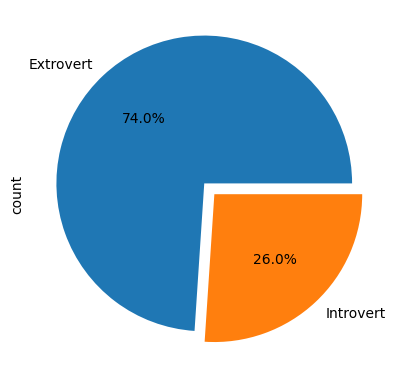

In [17]:
train['Personality'].value_counts().plot.pie(autopct='%1.1f%%',explode=[0.1,0]);  #autopct='%1.1f%%' sonuçları yüzdelik olarak gösterir. explode=[0.1,0,0,0,0,0] dilimleri diğer dilimlerden ayırır

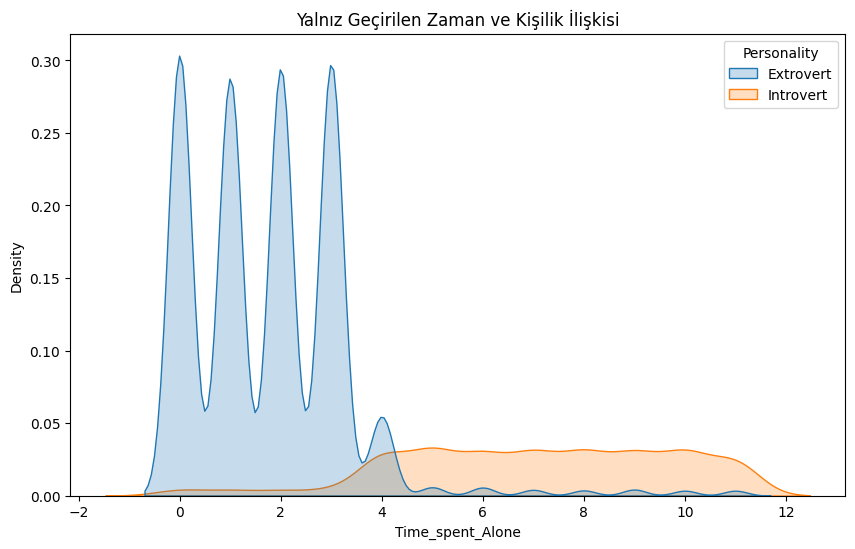

In [18]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=train, x='Time_spent_Alone', hue='Personality', fill=True)
plt.title('Yalnız Geçirilen Zaman ve Kişilik İlişkisi')
plt.show()

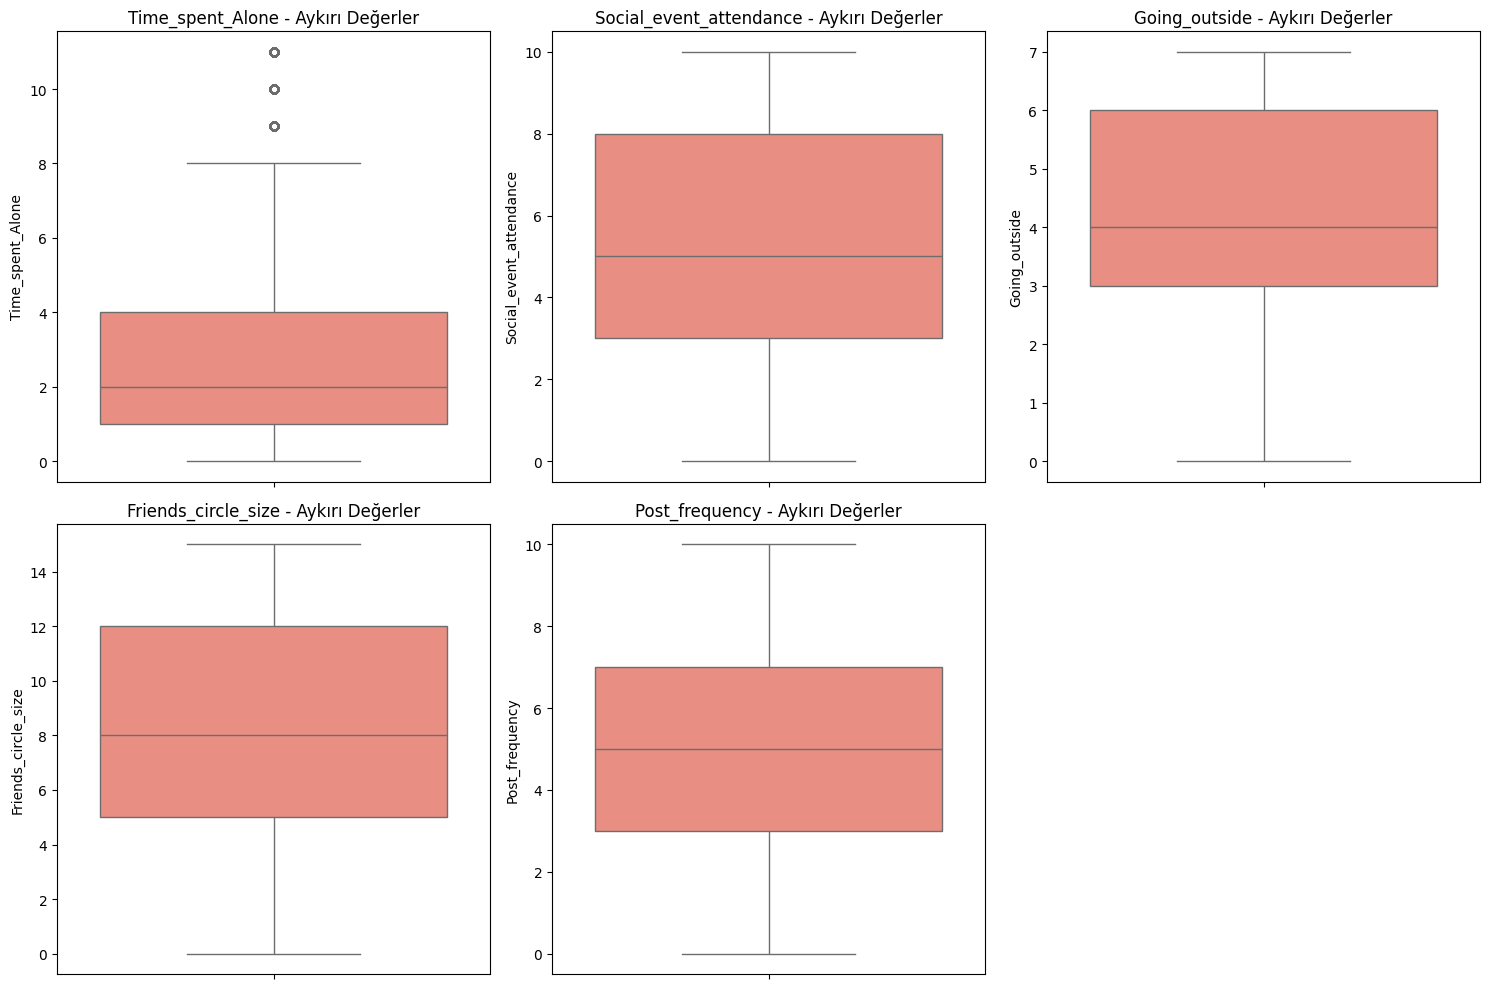

In [19]:
# Sayısal sütunları listeleyelim
num_cols = ['Time_spent_Alone', 'Social_event_attendance', 'Going_outside', 'Friends_circle_size', 'Post_frequency']

# Grafik alanını oluşturalım
plt.figure(figsize=(15, 10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=train[col], color='salmon')
    plt.title(f'{col} - Aykırı Değerler')

plt.tight_layout()
plt.show()

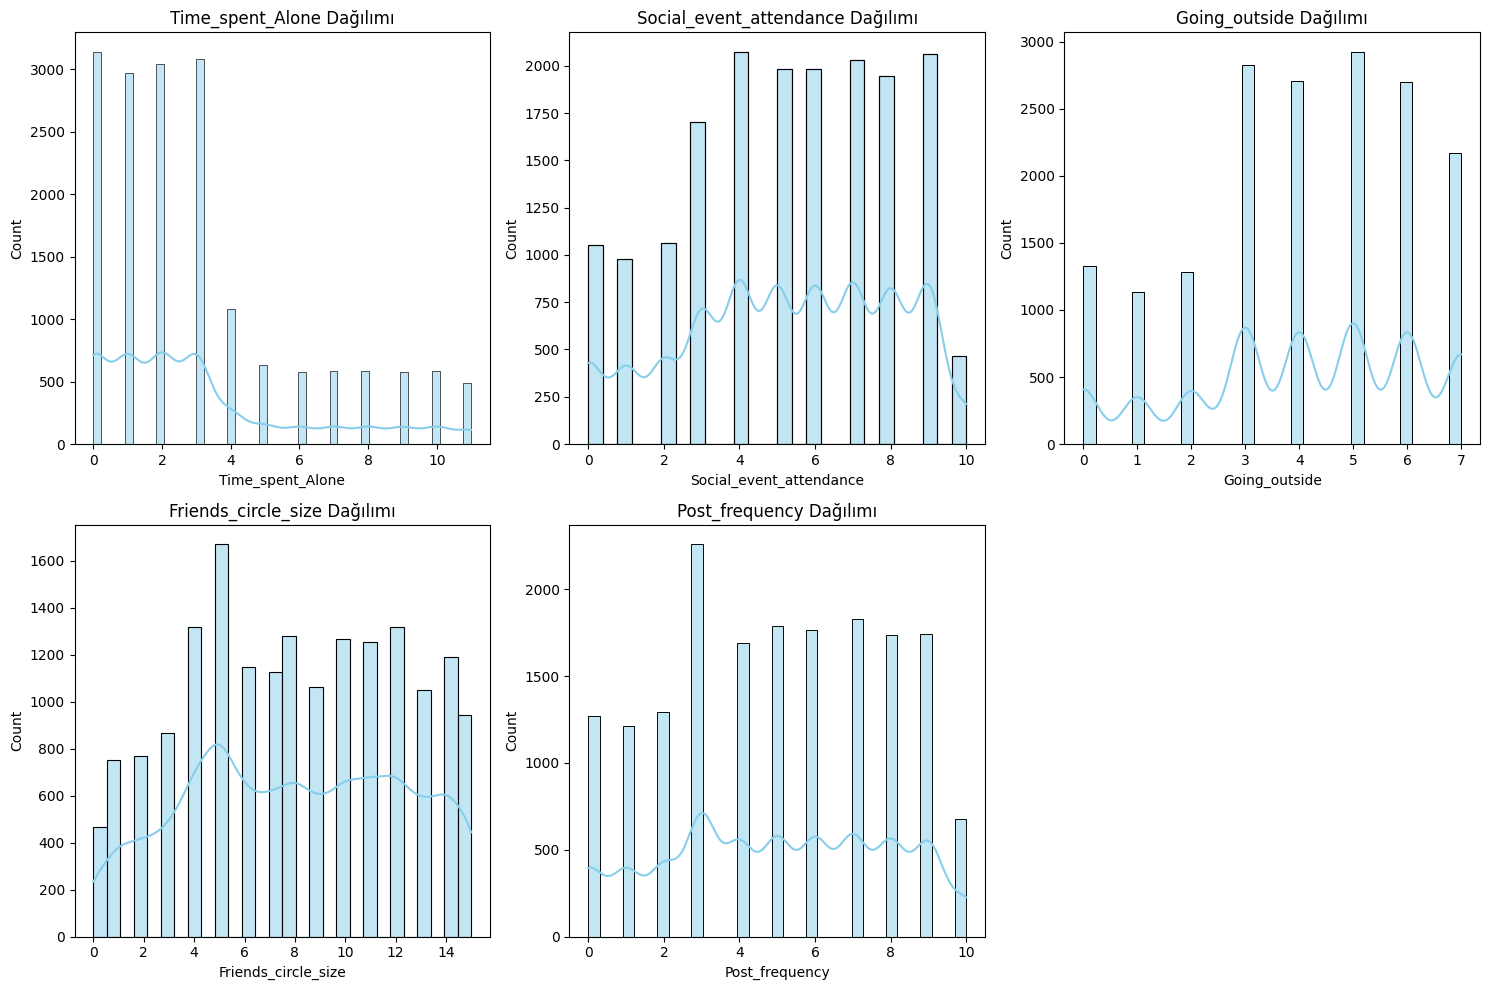

In [20]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(train[col], kde=True, color='skyblue')
    plt.title(f'{col} Dağılımı')

plt.tight_layout()
plt.show()

In [21]:
#Personality sütununu sayısala çevirelim
# Sözlüğü tanımlayalım
personality_mapping = {'Introvert': 0, 'Extrovert': 1}

#Introvert: İçe Dönük
#Extrovert: Dışa Dönük

# Train setindeki Personality sütununu dönüştürelim
train['Personality'] = train['Personality'].map(personality_mapping)

# Personality sütununu açıkça tam sayı (int) yapalım
train['Personality'] = train['Personality'].astype(int)

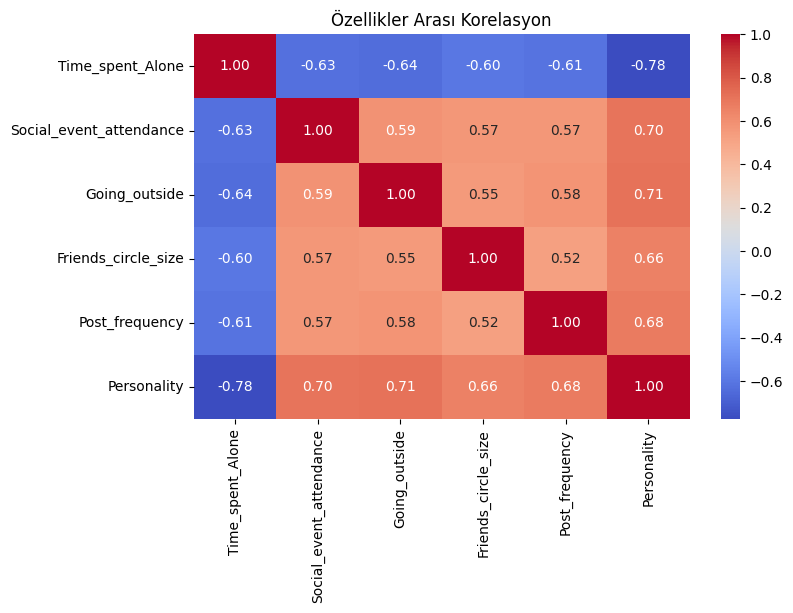

In [22]:
# Sadece sayısal sütunlar arasındaki korelasyona bakalım
plt.figure(figsize=(8, 5))
sns.heatmap(train[num_cols + ['Personality']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Özellikler Arası Korelasyon')
plt.show()

In [23]:
# veri setlerini birleştirip işleme devam ediyoruz

In [24]:
#hedefi ve ID'leri bir kenara alalım
hedef=train['Personality']
train_ids = train['id']
test_ids = test['id']

In [25]:
#train ve test dosyalarını sadece özellikler olacak şekilde birleştirelim
df=pd.concat([train.drop(['id', 'Personality'], axis=1), test.drop('id', axis=1)], axis=0).reset_index(drop=True)

In [26]:
#Aykırı Değer Törpüleme (Capping) Fonksiyonu
num_cols = ['Time_spent_Alone', 'Social_event_attendance', 'Going_outside', 'Friends_circle_size', 'Post_frequency']

def cap_outliers(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df[col] = df[col].clip(lower=lower, upper=upper)
    return df

df = cap_outliers(df, num_cols)

In [27]:
#sayısallaştırma
df_dummy=pd.get_dummies(df, drop_first=True)

In [28]:
# Eksik Verileri Doldurma (KNN Imputer - Akıllı Doldurma)
# n_neighbors=5 genellikle en dengeli sonucu verir
imputer = KNNImputer(n_neighbors=5)
df_imp=imputer.fit_transform(df_dummy)

In [29]:
# Veriyi tekrar DataFrame yapalım (Sütun isimlerini geri kazanalım)
df = pd.DataFrame(df_imp, columns=df_dummy.columns)

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24699 entries, 0 to 24698
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Time_spent_Alone               24699 non-null  float64
 1   Social_event_attendance        24699 non-null  float64
 2   Going_outside                  24699 non-null  float64
 3   Friends_circle_size            24699 non-null  float64
 4   Post_frequency                 24699 non-null  float64
 5   Stage_fear_Yes                 24699 non-null  float64
 6   Drained_after_socializing_Yes  24699 non-null  float64
dtypes: float64(7)
memory usage: 1.3 MB


In [31]:
#x ve y belirleme
#yukarıdaki satırda hedefi ve ID'leri bir kenara ayırmıştık, burada onları kullanıyoruz

# Tüm eğitim özelliklerini (id ve personality hariç her şey) X yapalım
x = df.iloc[:len(train_ids), :]

# Kenara ayırdığımız hedef değişkeni y yapalım
y = hedef

In [32]:
# Eğitim verilerinin bittiği yerden sonuna kadar olan kısım (Test verisi)
x_kaggle_test = df.iloc[len(train_ids):, :]

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import BernoulliNB

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

b = BernoulliNB()
l = LogisticRegression()
d = DecisionTreeClassifier()
r = RandomForestClassifier()
gb= GradientBoostingClassifier()
kn= KNeighborsClassifier()
ab= AdaBoostClassifier()
mn= MultinomialNB()

def algo_test(x, y):
    modeller=[ b, l, d, r, gb, kn, ab, mn]
    isimler=["BernoulliNB", "LogisticRegression", "DecisionTreeClassifier", 
             "RandomForestClassifier", "GradientBoostingClassifier", "KNeighborsClassifier",
             "AdaBoostClassifier", "MultinomialNB"]

    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.20, random_state = 42)
    
    accuracy = []
    precision = []
    recall = []
    f1 = []
    mdl=[]

    print("Veriler hazır modeller deneniyor")
    for model in modeller:
        print(model, " modeli eğitiliyor!..")
        model=model.fit(x_train,y_train)
        tahmin=model.predict(x_test)
        mdl.append(model)
        accuracy.append(accuracy_score(y_test, tahmin))
        precision.append(precision_score(y_test, tahmin, average="binary"))
        recall.append(recall_score(y_test, tahmin, average="binary"))
        f1.append(f1_score(y_test, tahmin, average="binary"))
        print(confusion_matrix(y_test, tahmin))

    print("Eğitim tamamlandı.")
    
    metrics=pd.DataFrame(columns=["Accuracy", "Precision", "Recall", "F1", "Model"], index=isimler)
    metrics["Accuracy"] = accuracy
    metrics["Precision"] = precision  
    metrics["Recall"] = recall
    metrics["F1"] = f1
    metrics["Model"]=mdl

    metrics.sort_values("F1", ascending=False, inplace=True)

    print("En başarılı model: ", metrics.iloc[0].name)
    model=metrics.iloc[0,-1]
    tahmin=model.predict(np.array(x_test) if model==kn else x_test)
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, tahmin))
    print("classification Report:")
    print(classification_report(y_test, tahmin))
    print("Diğer Modeller:")
    
    return metrics.drop("Model", axis=1)

In [34]:
algo_test(x,y)

Veriler hazır modeller deneniyor
BernoulliNB()  modeli eğitiliyor!..
[[ 883   69]
 [  50 2703]]
LogisticRegression()  modeli eğitiliyor!..
[[ 886   66]
 [  50 2703]]
DecisionTreeClassifier()  modeli eğitiliyor!..
[[ 849  103]
 [ 147 2606]]
RandomForestClassifier()  modeli eğitiliyor!..
[[ 876   76]
 [  55 2698]]
GradientBoostingClassifier()  modeli eğitiliyor!..
[[ 885   67]
 [  50 2703]]
KNeighborsClassifier()  modeli eğitiliyor!..
[[ 885   67]
 [  52 2701]]
AdaBoostClassifier()  modeli eğitiliyor!..
[[ 885   67]
 [  49 2704]]
MultinomialNB()  modeli eğitiliyor!..
[[ 886   66]
 [  51 2702]]
Eğitim tamamlandı.
En başarılı model:  AdaBoostClassifier
Confusion Matrix:
[[ 885   67]
 [  49 2704]]
classification Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94       952
           1       0.98      0.98      0.98      2753

    accuracy                           0.97      3705
   macro avg       0.96      0.96      0.96      3705
wei

,Accuracy,Precision,Recall,F1
AdaBoostClassifier,0.968691,0.975821,0.982201,0.979001
LogisticRegression,0.968691,0.976165,0.981838,0.978993
GradientBoostingClassifier,0.968421,0.975812,0.981838,0.978816
MultinomialNB,0.968421,0.976156,0.981475,0.978808
BernoulliNB,0.967881,0.975108,0.981838,0.978462
KNeighborsClassifier,0.967881,0.975795,0.981112,0.978446
RandomForestClassifier,0.964642,0.972603,0.980022,0.976298
DecisionTreeClassifier,0.932524,0.961979,0.946604,0.954229


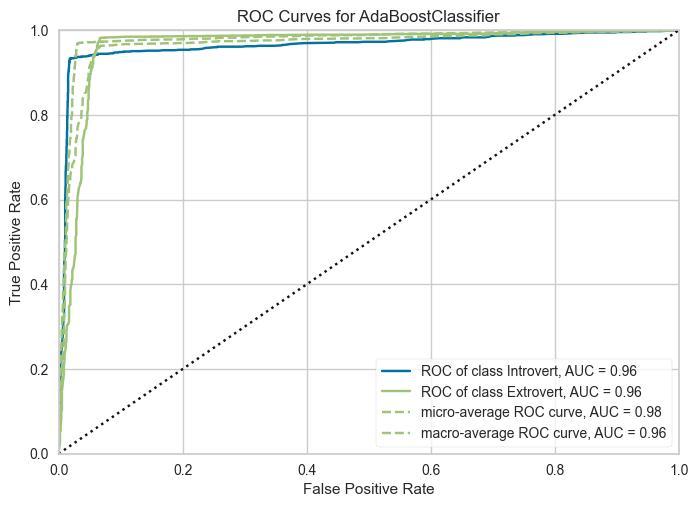

In [36]:
from yellowbrick.classifier import ROCAUC
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import train_test_split


# 1. Veriyi sadece bu analiz için bölelim
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# 2. AdaBoost görselleştiricisini tanımlayalım
visualizer = ROCAUC(AdaBoostClassifier(), classes=['Introvert', 'Extrovert'])

# 3. Eğit ve Görselleştir
visualizer.fit(x_train, y_train)        # Eğitim verisiyle öğret
visualizer.score(x_test, y_test)        # Hiç görmediği test verisiyle puanla
visualizer.show();                       # Grafiği göster

In [40]:
#en başarılı modeli tüm eğitim verisiyle tekrar eğitiyoruz

model=ab.fit(x,y)


In [41]:
#kaggle'ın beklediği test verisi üzerinden tahmin yapalım
tahmin=ab.predict(x_kaggle_test)

In [42]:
# Personality sütununa tahminleri geri yazalım (0-1'i tekrar kelimeye çevirelim)
# Map işleminin tersini yapıyoruz
ters_map = {0: 'Introvert', 1: 'Extrovert'}
final_df = pd.DataFrame({
    'id': test_ids, 
    'Personality': pd.Series(tahmin).map(ters_map)
})

# CSV olarak kaydedelim
final_df.to_csv('submission.csv', index=False)

In [44]:
# Modeli bir dosyaya kaydet
import joblib
joblib.dump(model, 'adaboost_personality_model.pkl')
print("Model başarıyla kaydedildi! ✅")

Model başarıyla kaydedildi! ✅
